In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as sklearn

In [2]:
train_df = pd.read_csv("../music_rec/train.csv")

df = train_df.copy()

In [3]:
drop_cols = [
    'Unnamed: 0',
    'artist_name',
    'track_name',
    'lyrics'
    'age'
    'genre'
    'topic'
]

The columns that are not expressed in numerics, such as artist and track names have been dropped. The redundant 'age' column has been dropped in favor of 'release_year'. 
The 'unnamed:0' column has also been excluded since it appears to be an automatically generated row index, and does not contain meaningful predictive information. 
'Genre' and 'topic' has also been dropped so that the semantic content of the songs are focused on, and to not have these two dominate the clustering with similar-sounding categorical names to the semantic labels. Future iterations could incorporate encoded genre features, however.

Correlation analysis during EDA revealed several semantically related feature pairs exhibiting partial overlap. However, because many of these variables also demonstrated meaningful independent variation, most semantic features were retained for preprocessing. PCA was later applied to reduce redundancy and compress correlated semantic information into lower-dimensional latent components.

In [4]:
semantic_cols = [
    'dating',
    'violence',
    'world/life',
    'night/time',
    'shake the audience',
    'family/gospel',
    'romantic',
    'communication',
    'obscene',
    'music',
    'movement/places',
    'light/visual perceptions',
    'family/spiritual',
    'sadness',
    'feelings',
    'release_date',
    'len'
]


X = df[semantic_cols]

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

K-Means uses Euclidean distance, so this must be scaled before clustering commences.

In [6]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

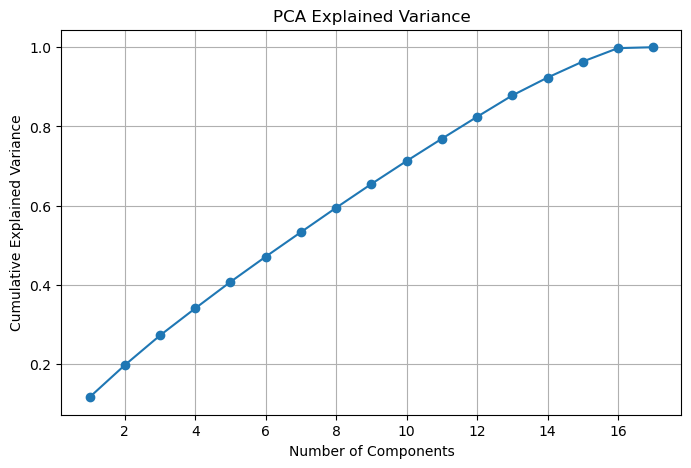

In [7]:
explained = np.cumsum(
    pca.explained_variance_ratio_
)

plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained)+1),
    explained,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")

plt.title("PCA Explained Variance")

plt.grid(True)

plt.show()

In [8]:
pca = PCA(n_components=0.9)

X_pca = pca.fit_transform(X_scaled)

PCA was initially performed without dimensionality constraints in order to inspect cumulative explained variance across components. Based on the resulting variance curve, a reduced PCA representation preserving approximately 90% of total variance was selected for subsequent clustering analysis.

In [9]:
pca_df = pd.DataFrame(
    X_pca,
    columns=[
        f"PC{i+1}"
        for i in range(X_pca.shape[1])
    ]
)

Created more convenient column headers when viewing PCA-transformed data.

In [47]:
pca_df.to_csv(
    "pca_train.csv",
    index=False
)

Saved PCA-transformed data for upcoming modelling section.

In [48]:
df.to_csv(
    "cleaned_train.csv",
    index=False
)

Saved the non-PCA cleaned dataframe, in case it's needed later when interpreting clusters.

In [37]:
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(pca, "pca.pkl")

['pca.pkl']